In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score

In [ ]:
data = pd.read_csv('nba_data.csv')
data.head()

,Name,GP,MIN,PTS,FGS,FGA,3PM,3PA,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,0.5,2.1,1.6,2.3,0.7,3.4,1.9,0.4,0.4,1.3,0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,0.7,2.8,2.6,3.4,0.5,2.0,3.7,1.1,0.5,1.6,0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,0.4,1.7,0.9,1.3,0.5,1.7,1.0,0.5,0.3,1.0,0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,0.1,0.5,0.9,1.3,1.0,0.9,0.8,0.6,0.1,1.0,1
4,Matt Geiger,48,11.5,4.5,1.6,3.0,0.0,0.1,1.3,1.9,1.0,1.5,0.3,0.3,0.4,0.8,1


In [ ]:
data['Successful'] = data['5Yrs'].replace({0: 'No', 1: 'Yes'})
data.head()

,Name,GP,MIN,PTS,FGS,FGA,3PM,3PA,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,5Yrs,Successful
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,0.5,2.1,1.6,2.3,0.7,3.4,1.9,0.4,0.4,1.3,0,No
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,0.7,2.8,2.6,3.4,0.5,2.0,3.7,1.1,0.5,1.6,0,No
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,0.4,1.7,0.9,1.3,0.5,1.7,1.0,0.5,0.3,1.0,0,No
3,Malik Sealy,58,11.6,5.7,2.3,5.5,0.1,0.5,0.9,1.3,1.0,0.9,0.8,0.6,0.1,1.0,1,Yes
4,Matt Geiger,48,11.5,4.5,1.6,3.0,0.0,0.1,1.3,1.9,1.0,1.5,0.3,0.3,0.4,0.8,1,Yes


In [ ]:
data['Successful'].value_counts()

Successful
Yes    816
No     492
Name: count, dtype: int64

In [ ]:
features=['GP', 'MIN', 'PTS', 'FGS', 'FGA', '3PM', '3PA', 'FTM', 'FTA', 'OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV']
data.groupby('Successful')[features].mean()

,GP,MIN,PTS,FGS,FGA,3PM,3PA,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV
Successful,,,,,,,,,,,,,,,
No,51.250000,14.155894,4.999390,1.929065,4.511585,0.231911,0.760366,0.912195,1.303862,0.711585,1.518496,1.211992,0.493699,0.250203,0.931911
Yes,65.828431,19.685172,7.862132,3.040809,6.692034,0.259436,0.794118,1.522426,2.123652,1.187745,2.328676,1.743873,0.691054,0.441422,1.344240


In [ ]:
data.groupby('Successful').agg({'PTS': ['count','mean', 'std']})

PTS                    
           count      mean       std
Successful                          
No           492  4.999390  3.074993
Yes          816  7.862132  4.616123

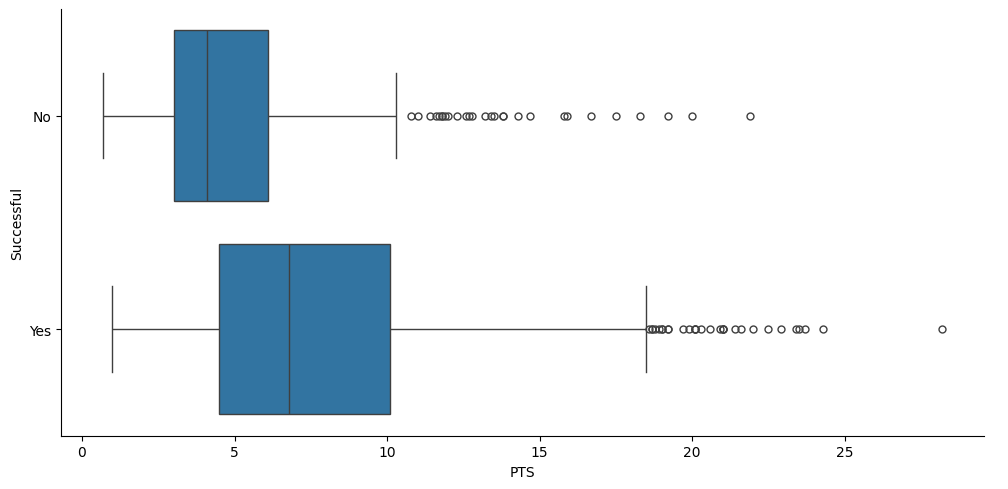

In [ ]:
sns.catplot(y='Successful', x='PTS', data=data, kind='box', aspect=2)

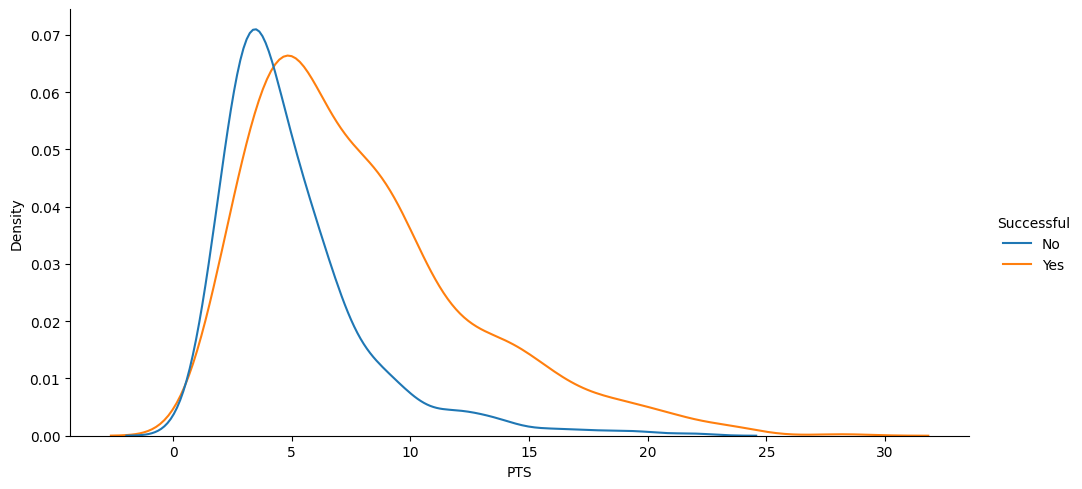

In [ ]:
sns.displot(data, x='PTS', hue='Successful', kind='kde', aspect=2)

In [ ]:
y = data['5Yrs']
all_features = ['GP', 'MIN', 'PTS', 'FGS', 'FGA', '3PM', '3PA', 'FTM', 'FTA', 'OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV']
X = data[all_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print("Size of X_train: ",X_train.shape)
print("Length of y_train: ",len(y_train))
print("Size of X_test: ",X_test.shape)
print("Length of y_test: ",len(y_test))

Size of X_train:  (1046, 15)
Length of y_train:  1046
Size of X_test:  (262, 15)
Length of y_test:  262


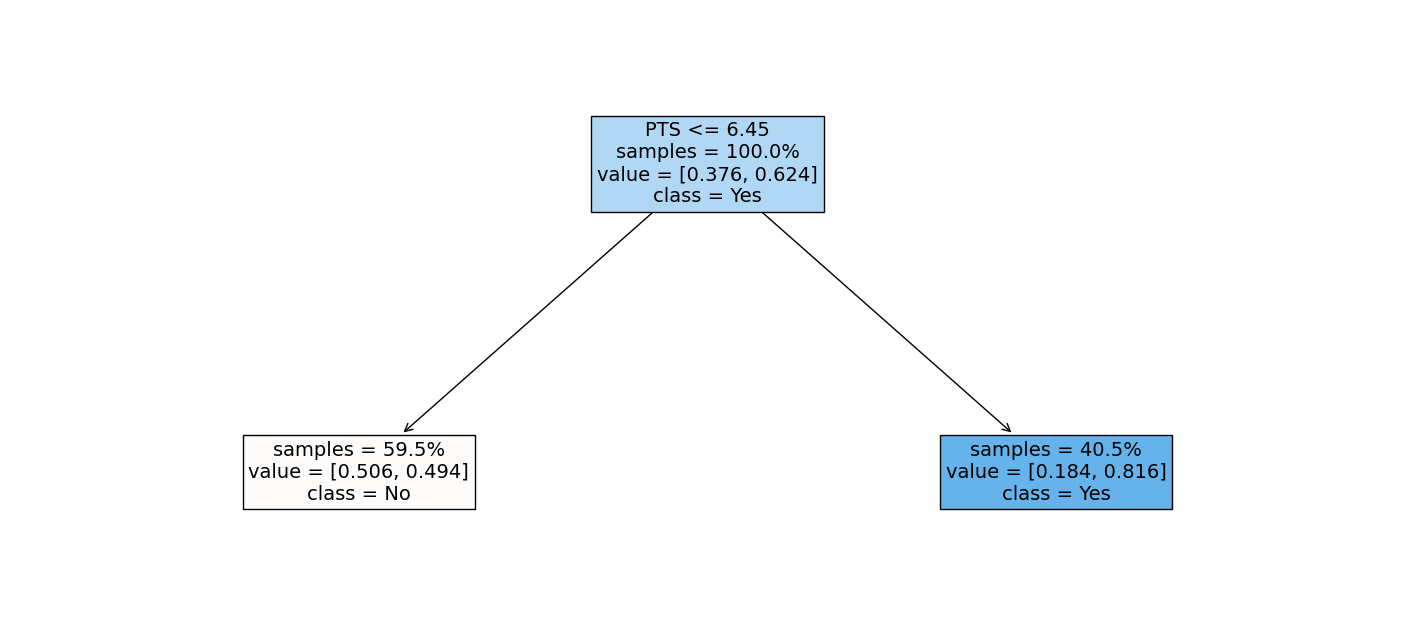

Precision:  0.7909090909090909
Recall:  0.5337423312883436


In [ ]:
input_features = ['PTS']
tree_model = DecisionTreeClassifier(max_depth=1).fit(X_train[input_features], y_train)

fig,ax = plt.subplots(figsize=(18,8))
plot_tree(tree_model,  filled=True, impurity=False, feature_names=input_features, proportion=True, class_names=["No", "Yes"], ax=ax, fontsize=14)
plt.show()
y_pred = tree_model.predict(X_test[input_features])
print("Precision: ",precision_score(y_test, y_pred))
print("Recall: ",recall_score(y_test, y_pred))

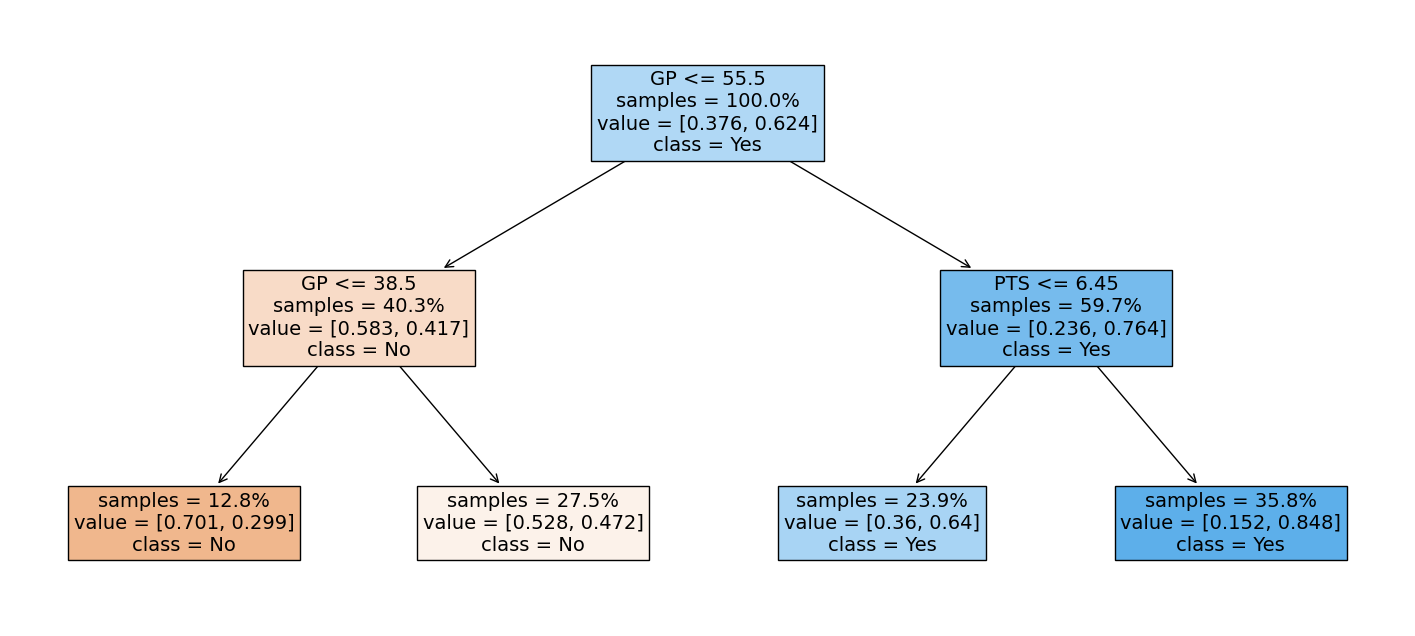

Precision:  0.7621951219512195
Recall:  0.7668711656441718


In [ ]:
input_features = ['PTS','GP']
tree_model = DecisionTreeClassifier(max_depth=2).fit(X_train[input_features], y_train)

fig,ax = plt.subplots(figsize=(18,8))
plot_tree(tree_model,  filled=True, impurity=False, feature_names=input_features, proportion=True, class_names=["No", "Yes"], ax=ax, fontsize=14)
plt.show()
y_pred = tree_model.predict(X_test[input_features])
print("Precision: ",precision_score(y_test, y_pred))
print("Recall: ",recall_score(y_test, y_pred))